<a href="https://colab.research.google.com/github/zahidah-23/GenderBridge/blob/main/MINIPROJECTML_YANGBETUL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Library

In [36]:
# =========================
# Data Manipulation
# =========================
import pandas as pd
import numpy as np

# =========================
# Data Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Preprocessing
# =========================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# =========================
# Machine Learning Models
# =========================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Definisi model
rf = RandomForestClassifier()


# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV


###Data Understanding

In [2]:
df = pd.read_csv('air_quality_health_impact_data.csv')

In [3]:
print("--- Info Dataset ---")
df.info()

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5811 entries, 0 to 5810
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RecordID             5811 non-null   int64  
 1   AQI                  5811 non-null   float64
 2   PM10                 5811 non-null   float64
 3   PM2_5                5811 non-null   float64
 4   NO2                  5811 non-null   float64
 5   SO2                  5811 non-null   float64
 6   O3                   5811 non-null   float64
 7   Temperature          5811 non-null   float64
 8   Humidity             5811 non-null   float64
 9   WindSpeed            5811 non-null   float64
 10  RespiratoryCases     5811 non-null   int64  
 11  CardiovascularCases  5811 non-null   int64  
 12  HospitalAdmissions   5811 non-null   int64  
 13  HealthImpactScore    5811 non-null   float64
 14  HealthImpactClass    5811 non-null   float64
dtypes: float64(11), i

In [4]:
print("\n--- Statistik Deskriptif ---")
df.describe(include='all')


--- Statistik Deskriptif ---


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
count,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000,5811.000000
mean,2906.000000,248.438476,148.654997,100.223714,102.293445,49.456838,149.312431,14.975500,54.776853,9.989177,9.974187,4.988986,2.001033,93.785223,0.281191
std,1677.635538,144.777638,85.698500,58.096612,57.713175,28.530329,86.534240,14.483067,26.020786,5.776950,3.129234,2.216791,1.398794,13.318904,0.714075
min,1.000000,0.005817,0.015848,0.031549,0.009625,0.011023,0.001661,-9.990998,10.001506,0.002094,1.000000,0.000000,0.000000,22.448488,0.000000
25%,1453.500000,122.951293,75.374954,49.435171,53.538538,24.887264,73.999665,2.481500,31.995262,4.952343,8.000000,3.000000,1.000000,98.203057,0.000000
50%,2906.000000,249.127841,147.634997,100.506337,102.987736,49.530165,149.559871,14.942428,54.543904,10.051742,10.000000,5.000000,2.000000,100.000000,0.000000
75%,4358.500000,373.630668,222.436759,151.340260,151.658516,73.346617,223.380126,27.465374,77.641639,14.971840,12.000000,6.000000,3.000000,100.000000,0.000000
max,5811.000000,499.858837,299.901962,199.984965,199.980195,99.969561,299.936812,39.963434,99.997493,19.999139,23.000000,14.000000,12.000000,100.000000,4.000000


In [5]:
print("\n--- Sampel Data ---")
df.head()


--- Sampel Data ---


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions,HealthImpactScore,HealthImpactClass
0,1,187.270059,295.853039,13.038560,6.639263,66.161150,54.624280,5.150335,84.424344,6.137755,7,5,1,97.244041,0.0
1,2,475.357153,246.254703,9.984497,16.318326,90.499523,169.621728,1.543378,46.851415,4.521422,10,2,0,100.000000,0.0
2,3,365.996971,84.443191,23.111340,96.317811,17.875850,9.006794,1.169483,17.806977,11.157384,13,3,0,100.000000,0.0
3,4,299.329242,21.020609,14.273403,81.234403,48.323616,93.161033,21.925276,99.473373,15.302500,8,8,1,100.000000,0.0
4,5,78.009320,16.987667,152.111623,121.235461,90.866167,241.795138,9.217517,24.906837,14.534733,9,0,1,95.182643,0.0


In [6]:
print(df['HealthImpactClass'].value_counts())


HealthImpactClass
0.0    4808
1.0     579
2.0     273
3.0      95
4.0      56
Name: count, dtype: int64


###Data Preprocessing

In [7]:

# Cek missing values
print(df.isnull().sum())
# (Jika ada missing, bisa isi atau drop)
df = df.dropna()


RecordID               0
AQI                    0
PM10                   0
PM2_5                  0
NO2                    0
SO2                    0
O3                     0
Temperature            0
Humidity               0
WindSpeed              0
RespiratoryCases       0
CardiovascularCases    0
HospitalAdmissions     0
HealthImpactScore      0
HealthImpactClass      0
dtype: int64


In [8]:
X = df.drop(columns=['HealthImpactClass'])

In [43]:
df.columns = df.columns.str.strip()

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\nKolom: {col}")
    print(f"Jumlah outlier: {len(outliers)}")


Kolom: RecordID
Jumlah outlier: 0

Kolom: AQI
Jumlah outlier: 0

Kolom: PM10
Jumlah outlier: 0

Kolom: PM2_5
Jumlah outlier: 0

Kolom: NO2
Jumlah outlier: 0

Kolom: SO2
Jumlah outlier: 0

Kolom: O3
Jumlah outlier: 0

Kolom: Temperature
Jumlah outlier: 0

Kolom: Humidity
Jumlah outlier: 0

Kolom: WindSpeed
Jumlah outlier: 0

Kolom: RespiratoryCases
Jumlah outlier: 42

Kolom: CardiovascularCases
Jumlah outlier: 74

Kolom: HospitalAdmissions
Jumlah outlier: 31

Kolom: HealthImpactScore
Jumlah outlier: 1352

Kolom: HealthImpactClass
Jumlah outlier: 1003


In [10]:
# -------------------------
# HANDLE OUTLIER (IQR)
# -------------------------
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Jangan ikutkan target
if 'HealthImpactClass' in numerical_cols:
    numerical_cols.remove('HealthImpactClass')

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Capping
    df[col] = np.where(df[col] < lower, lower, df[col])
    df[col] = np.where(df[col] > upper, upper, df[col])

# Pastikan target integer
df['HealthImpactClass'] = df['HealthImpactClass'].astype(int)

In [11]:
X = df.drop(['HealthImpactScore', 'HealthImpactClass'], axis=1)
y = df['HealthImpactClass']

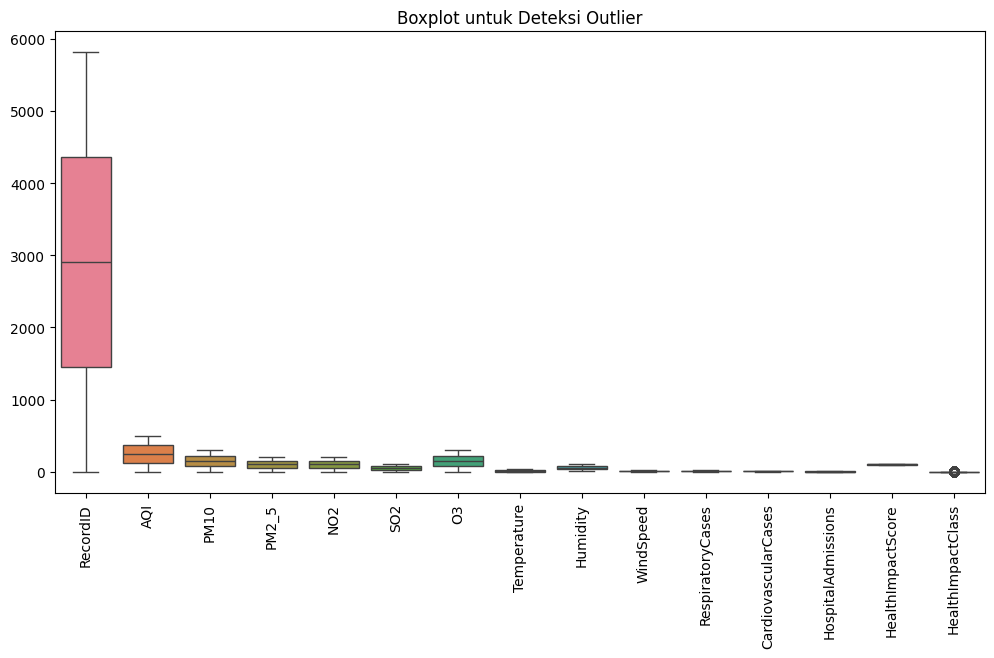

In [12]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.title("Boxplot untuk Deteksi Outlier")
plt.show()

In [13]:
#standarscaller
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [42]:
#Mengatasi data yang tidak seimbang
from imblearn.over_sampling import SMOTE

for split_name in splits:
    smote = SMOTE(random_state=42)

    X_train = splits[split_name]['X_train']
    y_train = splits[split_name]['y_train']

    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    splits[split_name]['X_train_smote'] = X_train_smote
    splits[split_name]['y_train_smote'] = y_train_smote

#EDA

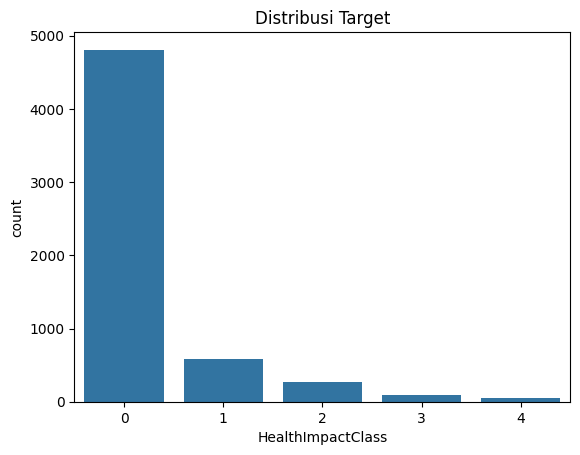

In [16]:
# Distribusi target
sns.countplot(x=df['HealthImpactClass'])
plt.title("Distribusi Target")
plt.show()

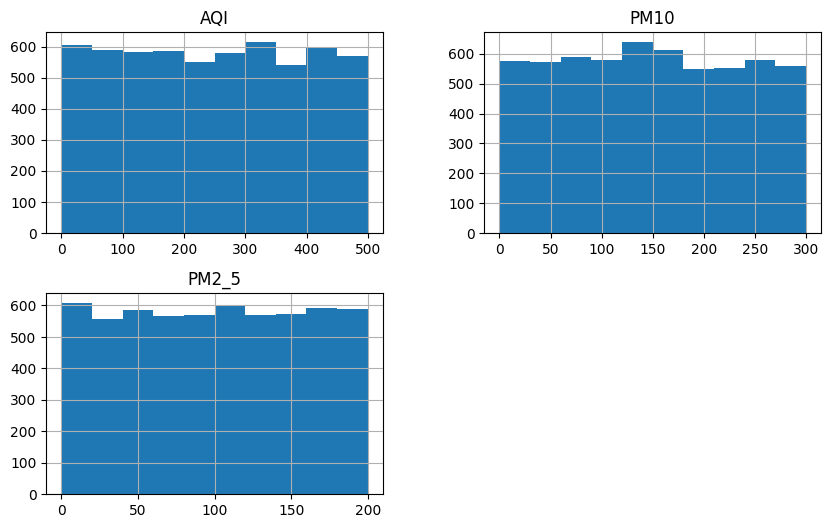

In [17]:
# Distribusi beberapa fitur
df[['AQI','PM10','PM2_5']].hist(figsize=(10,6))
plt.show()

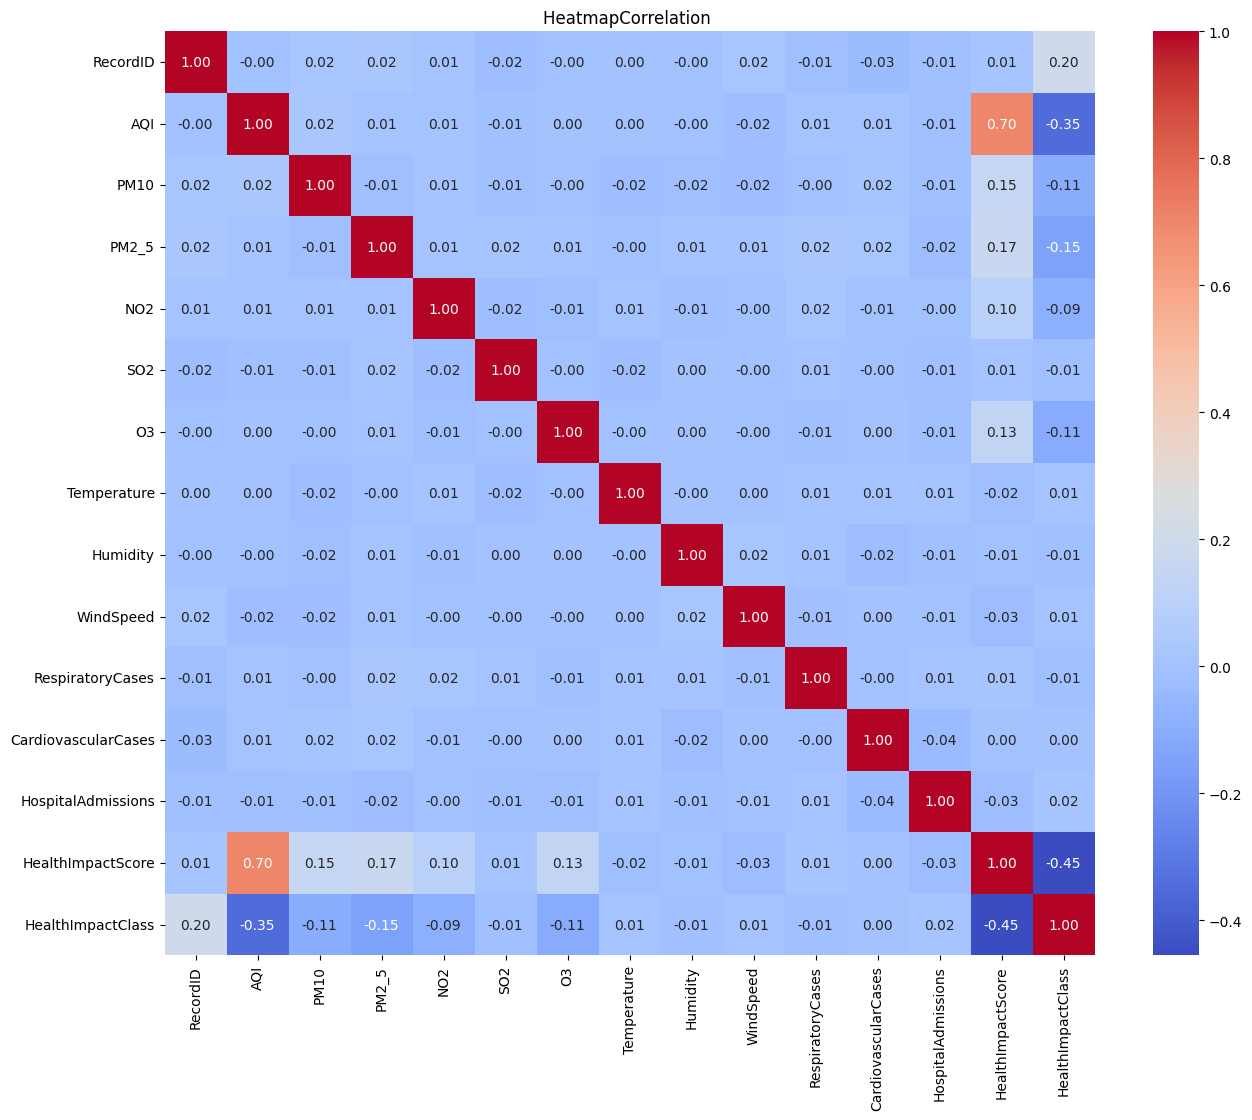

In [35]:
#Kolerasi
plt.figure(figsize=(15, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('HeatmapCorrelation ')
plt.show()

###Splitting Data

In [19]:
# Pisahkan fitur dan target
X = df.drop(columns=['HealthImpactClass'])
y = df['HealthImpactClass']

# Variasi split
split_ratios = [
    (0.3, '70/30'),
    (0.2, '80/20'),
    (0.1, '90/10')
]

splits = {}

for test_size, split_name in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    splits[split_name] = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test
    }

### Model building

In [20]:
models = {
    'Support Vector Machine': SVC(random_state=42, probability=True, class_weight='balanced'), # Added probability=True for consistent cross-validation scoring if needed
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', random_state=42)
}

###Hyperparameter tuning

In [21]:
#menentukan ruang pencarian hyperparameter
param_grids = {
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, None]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1]
    }
}

In [39]:

# Parameter khusus Random Forest
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, None]
    }
}

best_rf_models = {}

for split_name in splits:
    X_train = splits[split_name]['X_train_smote']
    y_train = splits[split_name]['y_train_smote']

    grid_rf = GridSearchCV(
        models['Random Forest'],
        param_grids['Random Forest'],
        cv=3,
        n_jobs=-1
    )

    grid_rf.fit(X_train, y_train)

    best_rf_models[split_name] = grid_rf.best_estimator_

    print(f"Random Forest selesai untuk split {split_name}")

Random Forest selesai untuk split 70/30
Random Forest selesai untuk split 80/20
Random Forest selesai untuk split 90/10


In [37]:
#hyperparameter tuning khusus model XGBoost
best_xgb_models = {}

for split_name in splits:
    X_train = splits[split_name]['X_train_smote']
    y_train = splits[split_name]['y_train_smote']

    grid_xgb = GridSearchCV(
        estimator=models['XGBoost'],
        param_grid=param_grids['XGBoost'],
        cv=2,
        n_jobs=-1,
        verbose=1
    )

    grid_xgb.fit(X_train, y_train)

    best_xgb_models[split_name] = grid_xgb.best_estimator_

    print(f"XGBoost selesai untuk split {split_name}")

Fitting 2 folds for each of 12 candidates, totalling 24 fits
XGBoost selesai untuk split 70/30
Fitting 2 folds for each of 12 candidates, totalling 24 fits
XGBoost selesai untuk split 80/20
Fitting 2 folds for each of 12 candidates, totalling 24 fits
XGBoost selesai untuk split 90/10


In [38]:
#hyperparameter tuning khusus model Support Vector Machine (SVM).
best_svm_models = {}

for split_name in splits:
    X_train = splits[split_name]['X_train_smote']
    y_train = splits[split_name]['y_train_smote']

    grid_svm = GridSearchCV(
        estimator=models['Support Vector Machine'],
        param_grid=param_grids['Support Vector Machine'],
        cv=2,
        n_jobs=-1,
        verbose=1
    )

    grid_svm.fit(X_train, y_train)

    best_svm_models[split_name] = grid_svm.best_estimator_

    print(f"Support Vector Machine selesai untuk split {split_name}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Support Vector Machine selesai untuk split 70/30
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Support Vector Machine selesai untuk split 80/20
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Support Vector Machine selesai untuk split 90/10


### 7. Model Evaluation

In [40]:
results = {}

for split_name in splits:
    X_test = splits[split_name]['X_test']
    y_test = splits[split_name]['y_test']

    print(f"\n--- Evaluating models for split: {split_name} ---")

    # Evaluate Random Forest
    rf_model = best_rf_models[split_name]
    y_pred_rf = rf_model.predict(X_test)
    print(f"\nRandom Forest ({split_name}):")
    print("Accuracy:", accuracy_score(y_test, y_pred_rf))
    print("Precision:", precision_score(y_test, y_pred_rf, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_rf, average='weighted', zero_division=0))
    print("F1-Score:", f1_score(y_test, y_pred_rf, average='weighted', zero_division=0))
    print("Classification Report:\n", classification_report(y_test, y_pred_rf, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

    # Evaluate XGBoost
    xgb_model = best_xgb_models[split_name]
    y_pred_xgb = xgb_model.predict(X_test)
    print(f"\nXGBoost ({split_name}):")
    print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
    print("Precision:", precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0))
    print("F1-Score:", f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0))
    print("Classification Report:\n", classification_report(y_test, y_pred_xgb, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

    # Evaluate SVM
    svm_model = best_svm_models[split_name]
    y_pred_svm = svm_model.predict(X_test)
    print(f"\nSupport Vector Machine ({split_name}):")
    print("Accuracy:", accuracy_score(y_test, y_pred_svm))
    print("Precision:", precision_score(y_test, y_pred_svm, average='weighted', zero_division=0))
    print("Recall:", recall_score(y_test, y_pred_svm, average='weighted', zero_division=0))
    print("F1-Score:", f1_score(y_test, y_pred_svm, average='weighted', zero_division=0))
    print("Classification Report:\n", classification_report(y_test, y_pred_svm, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

    results[split_name] = {
        'Random Forest': {
            'accuracy': accuracy_score(y_test, y_pred_rf),
            'precision': precision_score(y_test, y_pred_rf, average='weighted', zero_division=0),
            'recall': recall_score(y_test, y_pred_rf, average='weighted', zero_division=0),
            'f1_score': f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
        },
        'XGBoost': {
            'accuracy': accuracy_score(y_test, y_pred_xgb),
            'precision': precision_score(y_test, y_pred_xgb, average='weighted', zero_division=0),
            'recall': recall_score(y_test, y_pred_xgb, average='weighted', zero_division=0),
            'f1_score': f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)
        },
        'Support Vector Machine': {
            'accuracy': accuracy_score(y_test, y_pred_svm),
            'precision': precision_score(y_test, y_pred_svm, average='weighted', zero_division=0),
            'recall': recall_score(y_test, y_pred_svm, average='weighted', zero_division=0),
            'f1_score': f1_score(y_test, y_pred_svm, average='weighted', zero_division=0)
        }
    }


print("\n--- Summary of Model Evaluation Results ---")
for split_name, split_results in results.items():
    print(f"\nSplit: {split_name}")
    for model_name, metrics in split_results.items():
        print(f"  {model_name}:")
        for metric_name, value in metrics.items():
            print(f"    {metric_name.replace('_', ' ').capitalize()}: {value:.4f}")


--- Evaluating models for split: 70/30 ---

Random Forest (70/30):
Accuracy: 0.8841743119266054
Precision: 0.8968275459484996
Recall: 0.8841743119266054
F1-Score: 0.889103921696461
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96      1443
           1       0.57      0.72      0.64       174
           2       0.57      0.46      0.51        82
           3       0.18      0.21      0.20        28
           4       0.13      0.18      0.15        17

    accuracy                           0.88      1744
   macro avg       0.49      0.51      0.49      1744
weighted avg       0.90      0.88      0.89      1744

Confusion Matrix:
 [[1369   63    2    5    4]
 [  25  126   13    5    5]
 [   1   28   38    8    7]
 [   3    3   12    6    4]
 [   2    1    2    9    3]]

XGBoost (70/30):
Accuracy: 0.9030963302752294
Precision: 0.9078354340886587
Recall: 0.9030963302752294
F1-Score: 0.9051016143758014
Classificati

### Model Comparison

In [49]:

# data untuk comparison
comparison_data = []
for split_name, split_results in results.items():
    for model_name, metrics in split_results.items():
        row = {'Split': split_name, 'Model': model_name}
        row.update(metrics)
        comparison_data.append(row)

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df.round(4))


,Split,Model,accuracy,precision,recall,f1_score
0,70/30,Random Forest,0.8842,0.8968,0.8842,0.8891
1,70/30,XGBoost,0.9031,0.9078,0.9031,0.9051
2,70/30,Support Vector Machine,0.8865,0.8767,0.8865,0.8809
3,80/20,Random Forest,0.8899,0.9053,0.8899,0.8965
4,80/20,XGBoost,0.9063,0.9129,0.9063,0.9091
5,80/20,Support Vector Machine,0.8882,0.8788,0.8882,0.8833
6,90/10,Random Forest,0.8969,0.9071,0.8969,0.9003
7,90/10,XGBoost,0.9038,0.9024,0.9038,0.9025
8,90/10,Support Vector Machine,0.8832,0.8787,0.8832,0.8800


#### Visualizing Model Performance

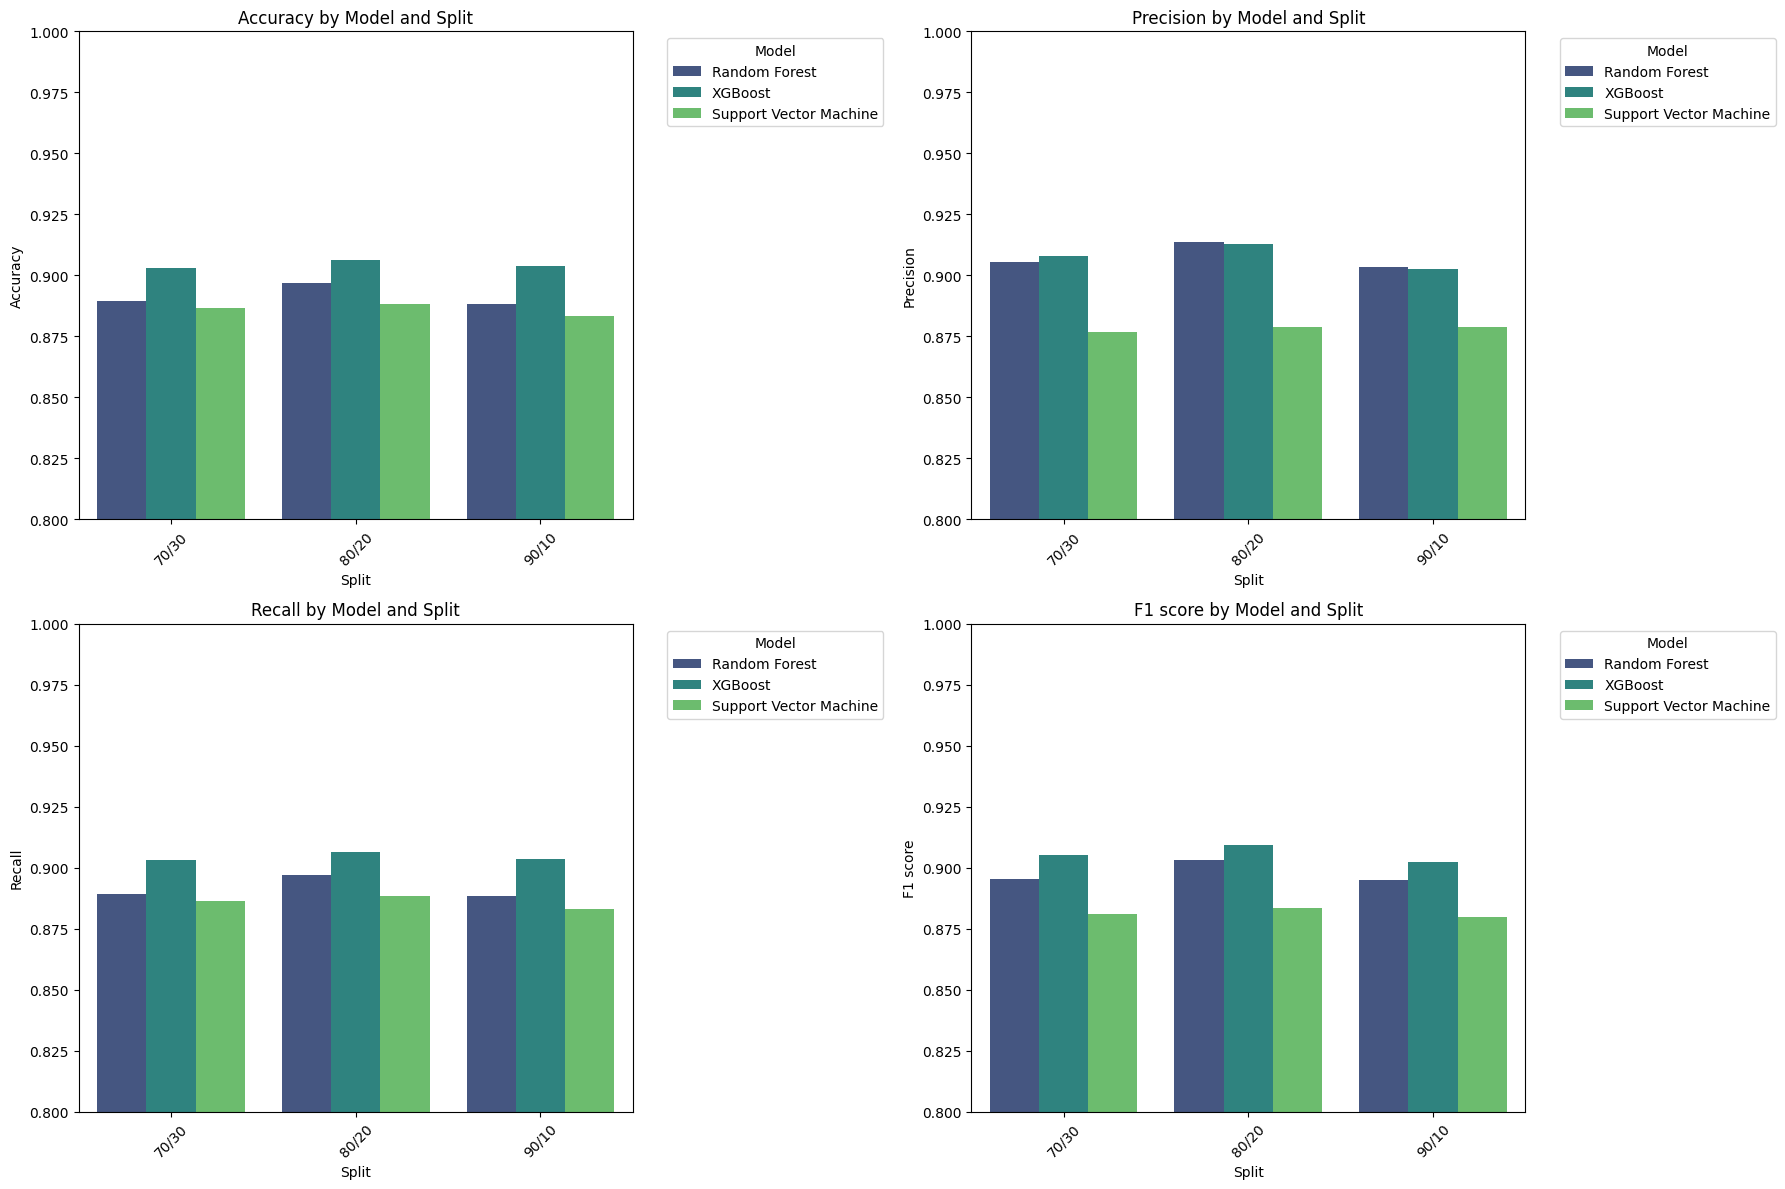

In [41]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']

plt.figure(figsize=(18, 12))

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(2, 2, i + 1)
    sns.barplot(x='Split', y=metric, hue='Model', data=comparison_df, palette='viridis')
    plt.title(f'{metric.replace("_", " ").capitalize()} by Model and Split')
    plt.ylabel(metric.replace("_", " ").capitalize())
    plt.ylim(0.8, 1.0)
    plt.xticks(rotation=45)
    plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Inference

In [47]:
# Memilih model terbaik (XGBoost dari split 80/20)
best_model = best_xgb_models['80/20']

# Mengambil scaler yang digunakan pada data asli
# Scaler ini di-fit pada X setelah menghapus kolom 'HealthImpactScore' dan 'HealthImpactClass'
scaler_for_inference = scaler

# Mendefinisikan kolom fitur yang digunakan saat training model
# Diasumsikan X dibuat dari df.drop(['HealthImpactScore', 'HealthImpactClass'], axis=1)
feature_columns = ['RecordID', 'AQI', 'PM10', 'PM2_5', 'NO2', 'SO2', 'O3', 'Temperature', 'Humidity', 'WindSpeed', 'RespiratoryCases', 'CardiovascularCases', 'HospitalAdmissions']

# Membuat contoh data baru untuk prediksi (data sintetis)
sample_new_data = pd.DataFrame({
    'RecordID': [9999, 10000, 10001],
    'AQI': [150.0, 300.0, 50.0],
    'PM10': [80.0, 180.0, 30.0],
    'PM2_5': [50.0, 120.0, 20.0],
    'NO2': [40.0, 90.0, 15.0],
    'SO2': [20.0, 60.0, 10.0],
    'O3': [100.0, 200.0, 50.0],
    'Temperature': [15.0, 25.0, 5.0],
    'Humidity': [60.0, 80.0, 40.0],
    'WindSpeed': [8.0, 15.0, 5.0],
    'RespiratoryCases': [5, 12, 3],
    'CardiovascularCases': [2, 7, 1],
    'HospitalAdmissions': [1, 4, 0],
    'HealthImpactScore': [98.0, 99.5, 96.0] # Kolom ini akan dihapus sebelum scaling
})

# Memastikan data hanya berisi kolom fitur dan urutannya sesuai dengan saat training
sample_new_data_for_inference = sample_new_data[feature_columns]

# Menerapkan scaling yang sama seperti saat training
sample_new_data_scaled = scaler_for_inference.transform(sample_new_data_for_inference)

# Melakukan prediksi menggunakan model terbaik
predictions = best_model.predict(sample_new_data_scaled)

print("Contoh Data Baru (fitur yang digunakan untuk prediksi):")
display(sample_new_data_for_inference)

print("\nHasil Prediksi Kelas Dampak Kesehatan:")
for i, pred in enumerate(predictions):
    print(f"Data ke-{i+1}: Kelas {pred}")

Contoh Data Baru (fitur yang digunakan untuk prediksi):


,RecordID,AQI,PM10,PM2_5,NO2,SO2,O3,Temperature,Humidity,WindSpeed,RespiratoryCases,CardiovascularCases,HospitalAdmissions
0,9999,150.0,80.0,50.0,40.0,20.0,100.0,15.0,60.0,8.0,5,2,1
1,10000,300.0,180.0,120.0,90.0,60.0,200.0,25.0,80.0,15.0,12,7,4
2,10001,50.0,30.0,20.0,15.0,10.0,50.0,5.0,40.0,5.0,3,1,0



Hasil Prediksi Kelas Dampak Kesehatan:
Data ke-1: Kelas 3
Data ke-2: Kelas 3
Data ke-3: Kelas 2
